# Final Project ML — Prediksi Kelayakan Air Minum
**Supervised Learning | Binary Classification | GridSearch + Multi-Scenario**

> Klasifikasi apakah sampel air layak diminum atau tidak berdasarkan parameter kimia air.

| Info | Detail |
|---|---|
| Dataset | Water Potability (Kaggle) |
| Jumlah Data | 3.276 baris |
| Fitur | 9 fitur numerik kontinu |
| Target | 1 = Layak, 0 = Tidak Layak |
| Pendekatan | Supervised Learning — Binary Classification |

**Pipeline:**
1. Load Data → EDA (Distribusi, Korelasi, Hypothesis Testing, PCA)
2. Preprocessing: Imputation → IQR Outlier Removal → Train-Test Split
3. GridSearchCV untuk tuning hyperparameter terbaik
4. Eksperimen 4 skenario: StandardScaler/MinMaxScaler × None/SMOTE
5. Evaluasi & perbandingan 6 model (Accuracy, Precision, Recall, F1, AUC)

## 1. Import Library

In [1]:
import pandas as pd
import numpy as np
import copy, warnings, time
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report,
                             roc_auc_score, roc_curve)
from sklearn.decomposition import PCA
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE

sns.set_theme(style='whitegrid', font_scale=1.0)
print("Success")

Success


## 2. Load Dataset

In [2]:
df = pd.read_csv('water_potability.csv')
print(f"Shape : {df.shape}")
print(f"\nMissing Values:\n{df.isnull().sum()}")
print(f"\nDistribusi Target:\n{df['Potability'].value_counts()}")
df.head()

Shape : (3276, 10)

Missing Values:
ph                 491
Hardness             0
Solids               0
Chloramines          0
Sulfate            781
Conductivity         0
Organic_carbon       0
Trihalomethanes    162
Turbidity            0
Potability           0
dtype: int64

Distribusi Target:
Potability
0    1998
1    1278
Name: count, dtype: int64


,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0


In [3]:
df.describe().round(2)

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
count,2785.00,3276.00,3276.00,3276.00,2495.00,3276.00,3276.00,3114.00,3276.00,3276.00
mean,7.08,196.37,22014.09,7.12,333.78,426.21,14.28,66.40,3.97,0.39
std,1.59,32.88,8768.57,1.58,41.42,80.82,3.31,16.18,0.78,0.49
min,0.00,47.43,320.94,0.35,129.00,181.48,2.20,0.74,1.45,0.00
25%,6.09,176.85,15666.69,6.13,307.70,365.73,12.07,55.84,3.44,0.00
50%,7.04,196.97,20927.83,7.13,333.07,421.88,14.22,66.62,3.96,0.00
75%,8.06,216.67,27332.76,8.11,359.95,481.79,16.56,77.34,4.50,1.00
max,14.00,323.12,61227.20,13.13,481.03,753.34,28.30,124.00,6.74,1.00


## 3. Exploratory Data Analysis (EDA)

### 3.1 Distribusi Target

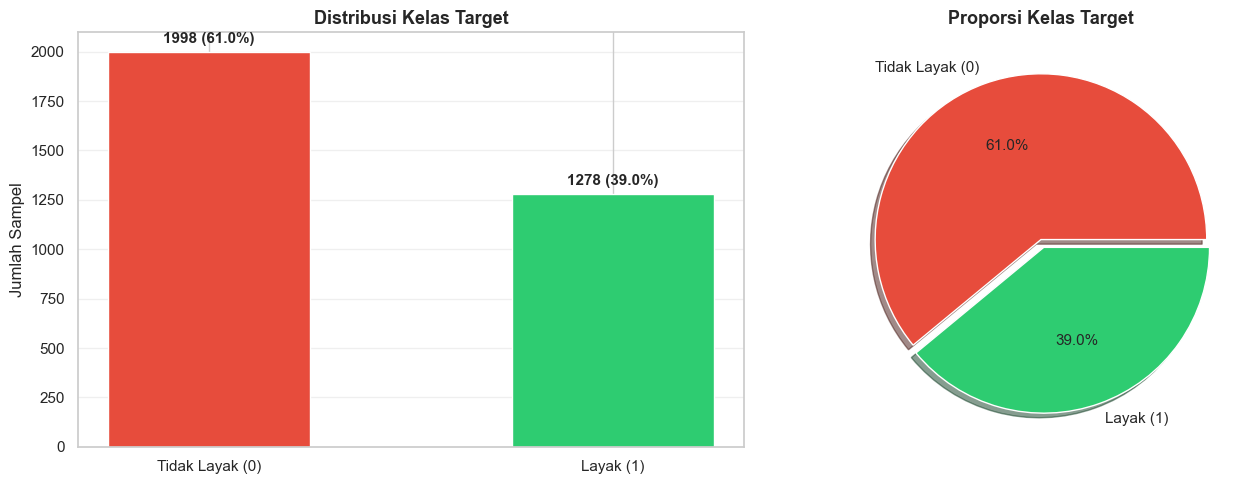


→ IMBALANCED: Rasio Tidak Layak : Layak = 1.56 : 1


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar plot
ax = axes[0]
counts = df['Potability'].value_counts().sort_index()
bars = ax.bar(['Tidak Layak (0)', 'Layak (1)'], counts.values,
              color=['#e74c3c', '#2ecc71'], edgecolor='white', width=0.5)
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
            f'{bar.get_height()} ({bar.get_height()/len(df)*100:.1f}%)',
            ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.set_title('Distribusi Kelas Target', fontsize=13, fontweight='bold')
ax.set_ylabel('Jumlah Sampel')
ax.grid(axis='y', alpha=0.3)

# Pie chart
ax = axes[1]
ax.pie(counts.values, labels=['Tidak Layak (0)', 'Layak (1)'],
       colors=['#e74c3c', '#2ecc71'], autopct='%.1f%%',
       shadow=True, explode=[0, 0.05], textprops={'fontsize': 11})
ax.set_title('Proporsi Kelas Target', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\n→ IMBALANCED: Rasio Tidak Layak : Layak = {counts[0]/counts[1]:.2f} : 1")

### 3.2 Boxplot Setiap Fitur

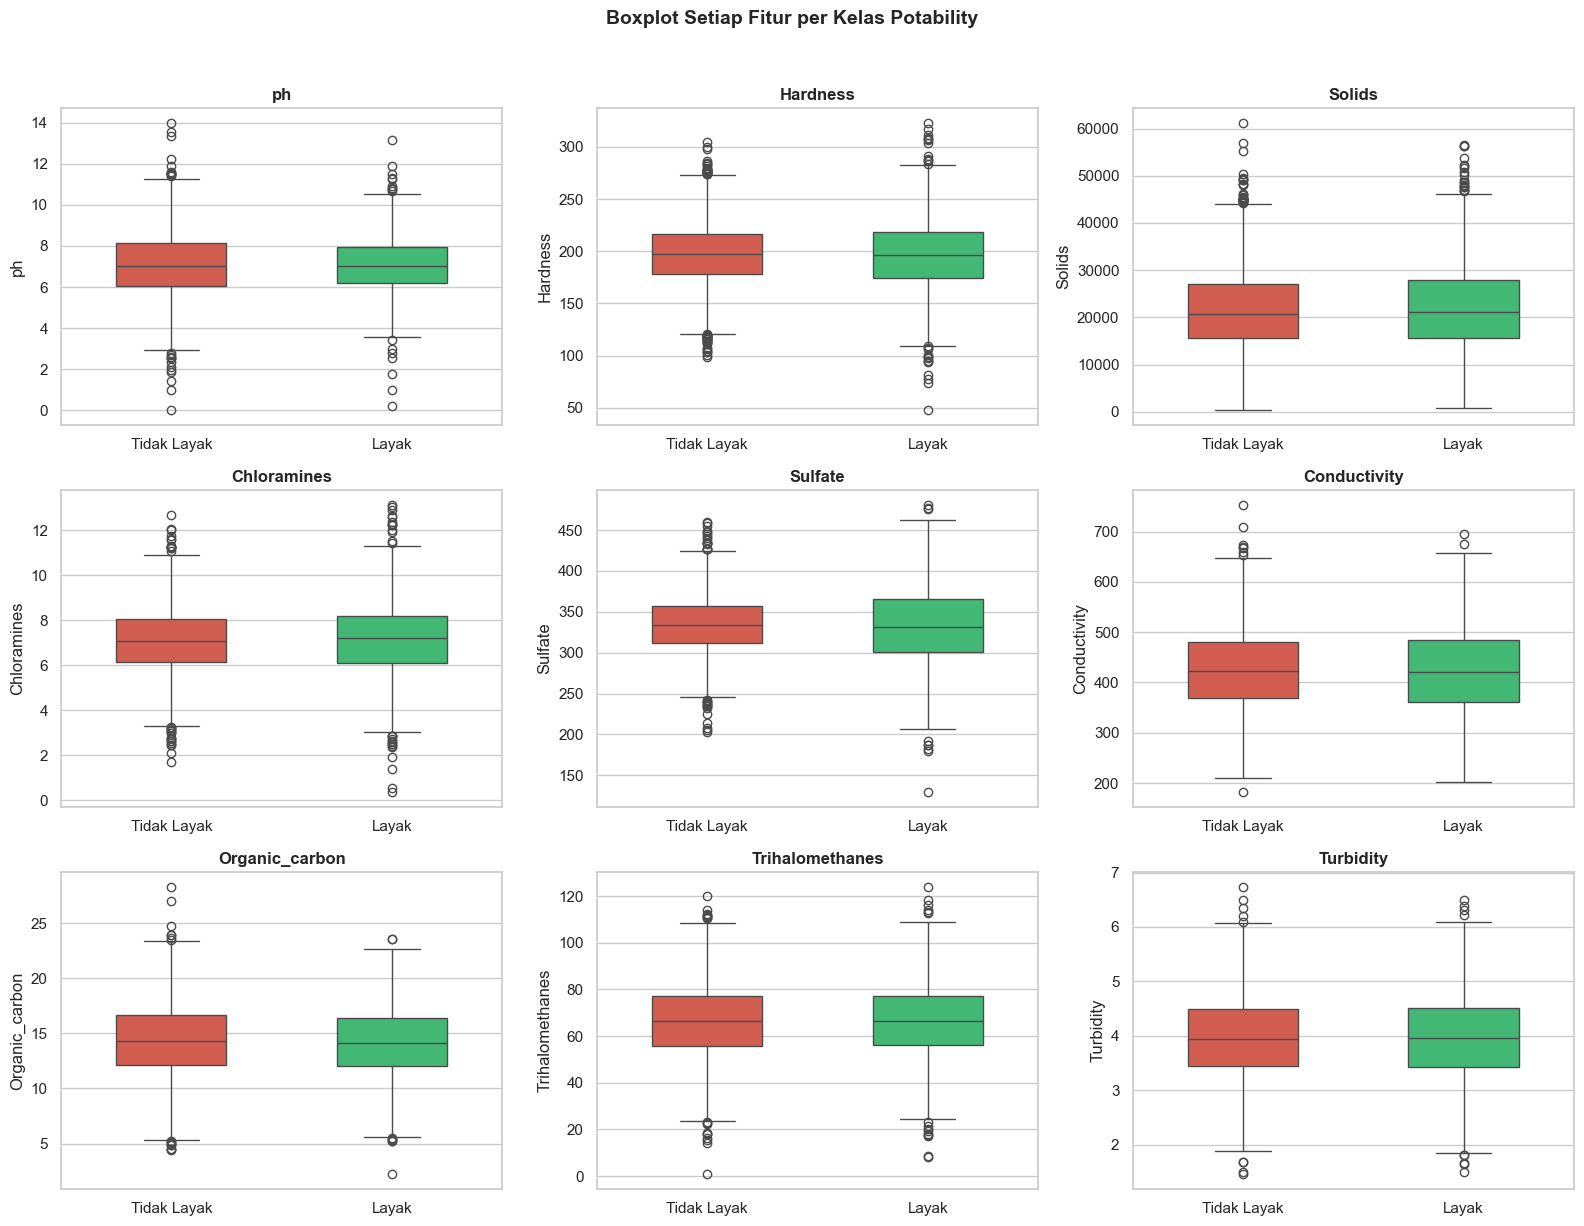

In [5]:
features = df.columns[:-1]

df_box = df.copy()
df_box['Kelas'] = df_box['Potability'].map({0: 'Tidak Layak', 1: 'Layak'})
box_order  = ['Tidak Layak', 'Layak']
box_palette = {'Tidak Layak': '#e74c3c', 'Layak': '#2ecc71'}

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes_flat = axes.flatten()

for i, col in enumerate(features):
    sns.boxplot(data=df_box, x='Kelas', y=col, order=box_order,
                palette=box_palette, ax=axes_flat[i], width=0.5)
    axes_flat[i].set_title(col, fontsize=12, fontweight='bold')
    axes_flat[i].set_xlabel('')

fig.suptitle('Boxplot Setiap Fitur per Kelas Potability', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 3.3 Distribusi Fitur per Kelas (KDE)
> Menganalisis perbedaan distribusi setiap fitur antara kelas Potable dan Non-Potable

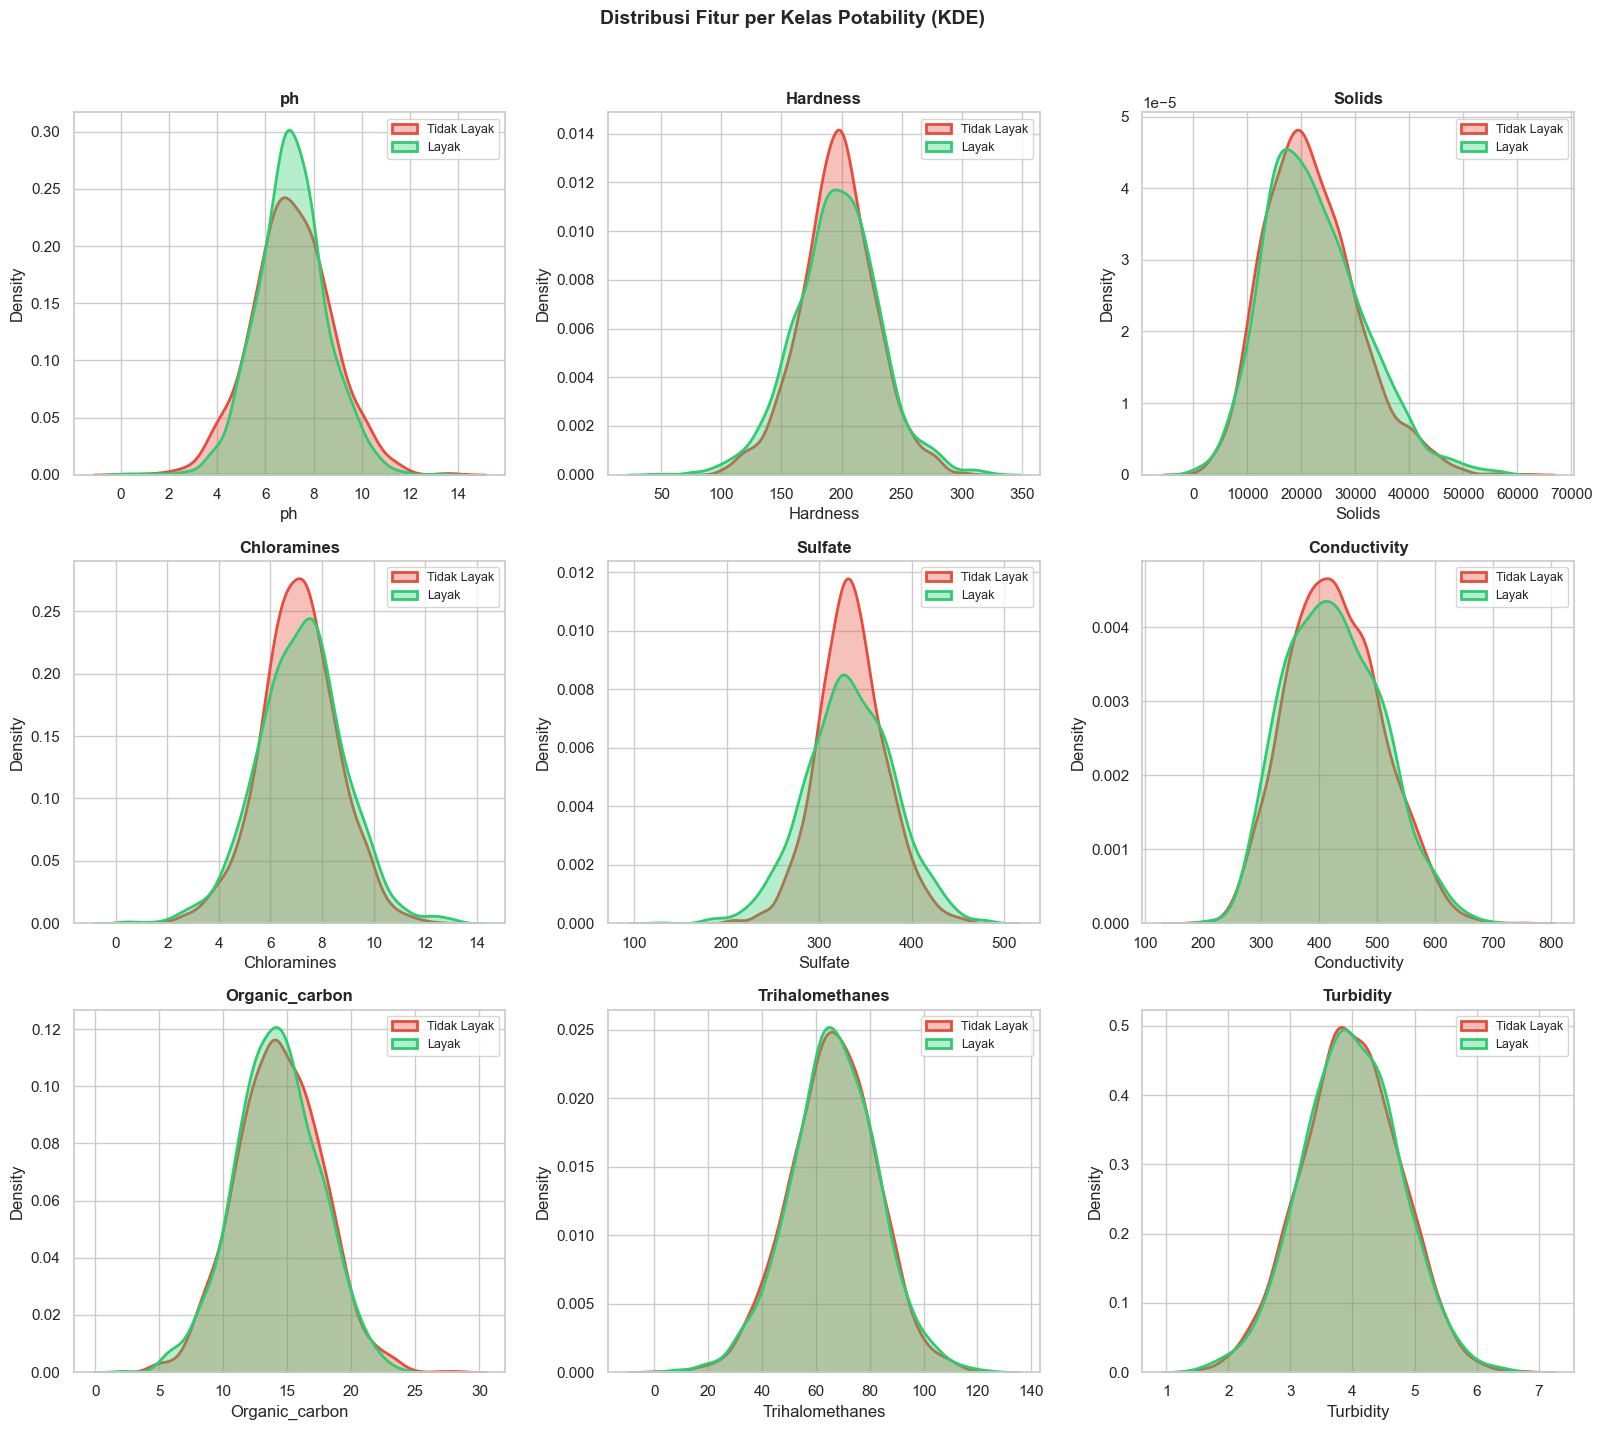

In [7]:
features = df.columns[:-1]
fig, axes = plt.subplots(3, 3, figsize=(16, 14))
axes_flat = axes.flatten()

for i, col in enumerate(features):
    for cls_label, color, cls_name in [(0, '#e74c3c', 'Tidak Layak'), (1, '#2ecc71', 'Layak')]:
        subset = df[df['Potability'] == cls_label][col].dropna()
        sns.kdeplot(subset, ax=axes_flat[i], fill=True, alpha=0.35,
                    color=color, linewidth=2, label=cls_name)
    axes_flat[i].set_title(col, fontsize=12, fontweight='bold')
    axes_flat[i].legend(fontsize=9)

fig.suptitle('Distribusi Fitur per Kelas Potability (KDE)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


### 3.4 Korelasi antar Fitur

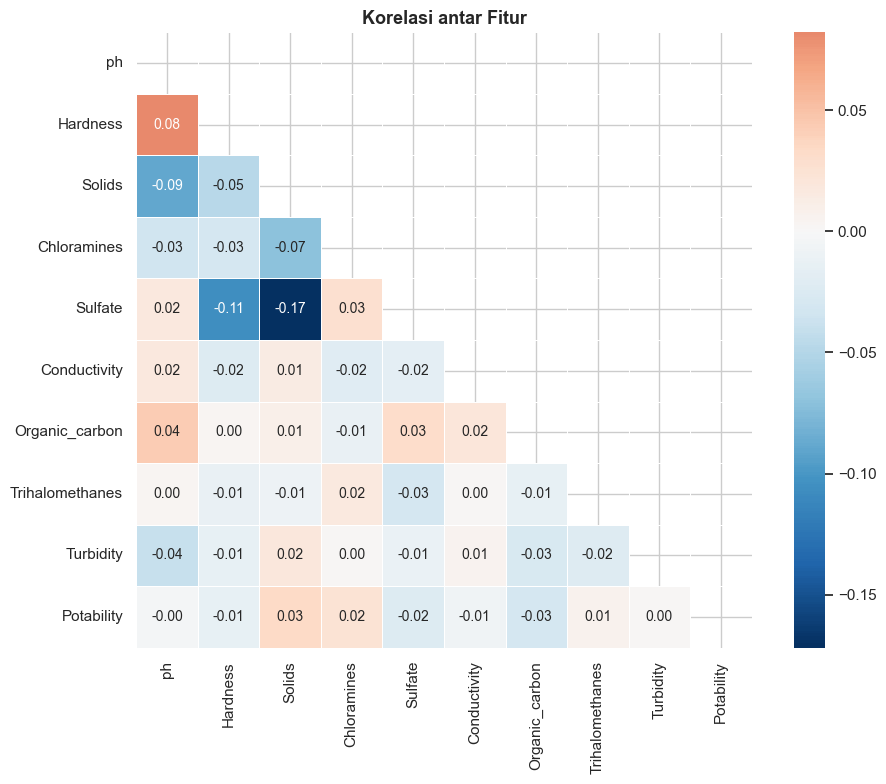

→ Tidak ada korelasi kuat antar fitur (independen)
→ Korelasi dengan target (Potability) rendah


In [9]:
fig, ax = plt.subplots(figsize=(10, 8))
corr = df.corr(numeric_only=True)
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, ax=ax, linewidths=0.5, square=True,
            annot_kws={'size': 10})
ax.set_title('Korelasi antar Fitur', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("→ Tidak ada korelasi kuat antar fitur (independen)")
print("→ Korelasi dengan target (Potability) rendah")

### 3.5 Hypothesis Testing (Independent t-test)
> Menguji apakah rata-rata setiap fitur berbeda secara signifikan antara kelas Potable vs Non-Potable

- **H₀**: Rata-rata fitur sama antara kedua kelas
- **H₁**: Rata-rata fitur berbeda secara signifikan
- **Significance level**: α = 0.10

HYPOTHESIS TESTING — Independent Samples t-test (α = 0.10)
  ph                   | p = 0.8512 | ✅ Accept H₀
  Hardness             | p = 0.4285 | ✅ Accept H₀
  Solids               | p = 0.0535 | ❌ Reject H₀ (signifikan)
  Chloramines          | p = 0.1736 | ✅ Accept H₀
  Sulfate              | p = 0.2391 | ✅ Accept H₀
  Conductivity         | p = 0.6419 | ✅ Accept H₀
  Organic_carbon       | p = 0.0860 | ❌ Reject H₀ (signifikan)
  Trihalomethanes      | p = 0.6908 | ✅ Accept H₀
  Turbidity            | p = 0.9279 | ✅ Accept H₀


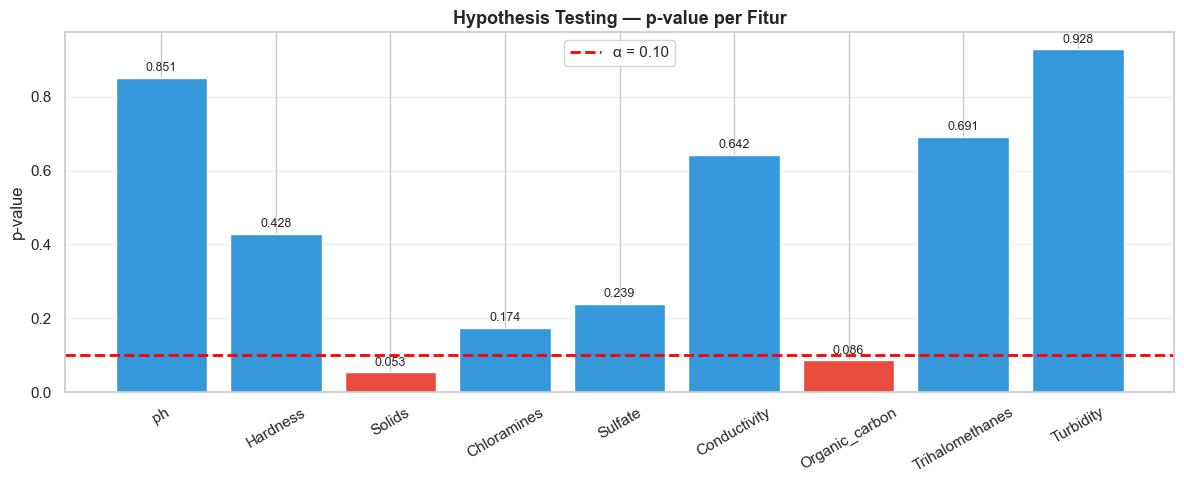


→ Fitur signifikan (p < 0.10): ['Solids', 'Organic_carbon']
→ Mayoritas fitur tidak membedakan kedua kelas secara statistik


In [12]:
features = df.columns[:-1]
results_ttest = []

print("=" * 75)
print("HYPOTHESIS TESTING — Independent Samples t-test (α = 0.10)")
print("=" * 75)

for col in features:
    potable = df[df['Potability'] == 1][col].dropna()
    not_potable = df[df['Potability'] == 0][col].dropna()
    stat, p_val = ttest_ind(potable, not_potable)
    sig = p_val < 0.10
    results_ttest.append({'Feature': col, 'p-value': round(p_val, 4), 'Significant': sig})
    status = "❌ Reject H₀ (signifikan)" if sig else "✅ Accept H₀"
    print(f"  {col:20s} | p = {p_val:.4f} | {status}")

print("=" * 75)

# Plot p-values
df_ttest = pd.DataFrame(results_ttest)
fig, ax = plt.subplots(figsize=(12, 5))
colors_t = ['#e74c3c' if s else '#3498db' for s in df_ttest['Significant']]
bars = ax.bar(df_ttest['Feature'], df_ttest['p-value'], color=colors_t, edgecolor='white')
ax.axhline(y=0.10, color='red', linestyle='--', linewidth=2, label='α = 0.10')
for bar, pv in zip(bars, df_ttest['p-value']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{pv:.3f}', ha='center', va='bottom', fontsize=9)
ax.set_title('Hypothesis Testing — p-value per Fitur', fontsize=13, fontweight='bold')
ax.set_ylabel('p-value')
ax.legend(fontsize=11)
ax.tick_params(axis='x', rotation=30)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

sig_features = [r['Feature'] for r in results_ttest if r['Significant']]
print(f"\n→ Fitur signifikan (p < 0.10): {sig_features if sig_features else 'Tidak ada'}")
print("→ Mayoritas fitur tidak membedakan kedua kelas secara statistik")

### 3.6 PCA — Explained Variance Analysis
> Menganalisis apakah dimensionality reduction diperlukan

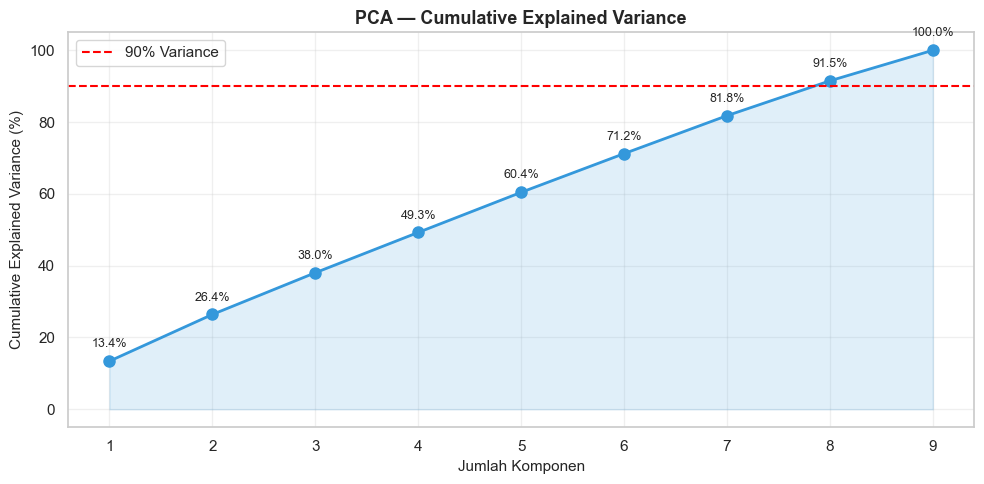


→ Dibutuhkan 8 komponen untuk menjelaskan ≥90% variansi
→ Fitur relatif independen


In [14]:
# tanpa missing values
temp = df.dropna()
X_pca = StandardScaler().fit_transform(temp.drop('Potability', axis=1))

pca = PCA()
pca.fit(X_pca)
explained = np.cumsum(pca.explained_variance_ratio_) * 100

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(range(1, len(explained)+1), explained, 'o-', color='#3498db',
        linewidth=2, markersize=8)
ax.fill_between(range(1, len(explained)+1), explained, alpha=0.15, color='#3498db')
ax.axhline(y=90, color='red', linestyle='--', linewidth=1.5, label='90% Variance')
for i, v in enumerate(explained):
    ax.annotate(f'{v:.1f}%', (i+1, v), textcoords="offset points",
                xytext=(0, 10), ha='center', fontsize=9)
ax.set_xlabel('Jumlah Komponen', fontsize=11)
ax.set_ylabel('Cumulative Explained Variance (%)', fontsize=11)
ax.set_title('PCA — Cumulative Explained Variance', fontsize=13, fontweight='bold')
ax.set_xticks(range(1, len(explained)+1))
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

n_90 = int(np.argmax(explained >= 90) + 1)
print(f"\n→ Dibutuhkan {n_90} komponen untuk menjelaskan ≥90% variansi")
print("→ Fitur relatif independen")

## 4. Preprocessing

### 4.1 Imputasi Missing Values (Group-wise Median)
> Mengisi missing values berdasarkan **median per kelas Potability**, bukan median global.
> Pendekatan ini lebih akurat karena mempertahankan distribusi per kelas.

In [15]:
print("Missing values SEBELUM imputasi:")
print(df[['ph', 'Sulfate', 'Trihalomethanes']].isnull().sum())
print()

# Group-wise median imputation berdasarkan kelas Potability
for col in ['ph', 'Sulfate', 'Trihalomethanes']:
    df[col] = df[col].fillna(df.groupby('Potability')[col].transform('median'))

print("Missing values SETELAH imputasi:")
print(df.isnull().sum())
print(f"\nTotal data: {len(df)} baris")
print("\n→ Imputasi group-wise median mempertahankan distribusi per kelas")

Missing values SEBELUM imputasi:
ph                 491
Sulfate            781
Trihalomethanes    162
dtype: int64

Missing values SETELAH imputasi:
ph                 0
Hardness           0
Solids             0
Chloramines        0
Sulfate            0
Conductivity       0
Organic_carbon     0
Trihalomethanes    0
Turbidity          0
Potability         0
dtype: int64

Total data: 3276 baris

→ Imputasi group-wise median mempertahankan distribusi per kelas


### 4.2 IQR Outlier Removal

In [16]:
def remove_outliers_iqr(data, columns, multiplier=1.5):
    """Hapus outlier menggunakan metode IQR."""
    df_clean = data.copy()
    total_removed = 0
    for col in columns:
        Q1 = df_clean[col].quantile(0.25)
        Q3 = df_clean[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - multiplier * IQR
        upper = Q3 + multiplier * IQR
        before = len(df_clean)
        df_clean = df_clean[(df_clean[col] >= lower) & (df_clean[col] <= upper)]
        removed = before - len(df_clean)
        total_removed += removed
        if removed > 0:
            print(f"  {col}: {removed} outlier dihapus (range: [{lower:.2f}, {upper:.2f}])")
    return df_clean, total_removed

before = len(df)
feature_cols = df.columns[:-1].tolist()
df, total_removed = remove_outliers_iqr(df, feature_cols)

print(f"\n→ Total outlier dihapus: {total_removed} baris ({total_removed/before*100:.1f}%)")
print(f"→ Sisa data: {len(df)} baris")

  ph: 142 outlier dihapus (range: [3.89, 10.26])
  Hardness: 74 outlier dihapus (range: [118.27, 275.68])
  Solids: 41 outlier dihapus (range: [-1629.65, 44493.93])
  Chloramines: 52 outlier dihapus (range: [3.19, 11.06])
  Sulfate: 229 outlier dihapus (range: [268.09, 399.81])
  Conductivity: 7 outlier dihapus (range: [192.17, 654.76])
  Organic_carbon: 15 outlier dihapus (range: [5.29, 23.38])
  Trihalomethanes: 41 outlier dihapus (range: [26.09, 107.58])
  Turbidity: 18 outlier dihapus (range: [1.84, 6.09])

→ Total outlier dihapus: 619 baris (18.9%)
→ Sisa data: 2657 baris


### 4.3 Train-Test Split (80:20 Stratified)

In [17]:
X = df.drop('Potability', axis=1)
y = df['Potability']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train set: {X_train.shape[0]} sampel")
print(f"Test set:  {X_test.shape[0]} sampel")
print(f"\nDistribusi target (train):\n{y_train.value_counts()}")
print(f"\nDistribusi target (test):\n{y_test.value_counts()}")


Train set: 2125 sampel
Test set:  532 sampel

Distribusi target (train):
Potability
0    1331
1     794
Name: count, dtype: int64

Distribusi target (test):
Potability
0    333
1    199
Name: count, dtype: int64


## 5. GridSearchCV — Hyperparameter Tuning

Tuning hyperparameter **6 model** menggunakan **5-Fold Stratified CV** dengan metrik **F1-Score**.

| Model | Hyperparameter yang Dituning |
|---|---|
| Decision Tree | max_depth, min_samples_split, class_weight |
| k-NN | n_neighbors, weights, p |
| Random Forest | n_estimators, max_depth, min_samples_split, max_features |
| Gradient Boosting | n_estimators, learning_rate, max_depth |
| SVM | C, kernel, gamma, class_weight |
| XGBoost | n_estimators, learning_rate, max_depth |

In [18]:
model_configs = {
    'Decision Tree': {
        'model': DecisionTreeClassifier(random_state=42),
        'params': {
            'max_depth': [3, 5, 7, 10, None],
            'min_samples_split': [2, 5, 10],
            'class_weight': ['balanced', None],
        }
    },
    'k-NN': {
        'model': KNeighborsClassifier(),
        'params': {
            'n_neighbors': [3, 5, 7, 9, 11, 15, 21],
            'weights': ['uniform', 'distance'],
            'p': [1, 2],
        }
    },
    'Random Forest': {
        'model': RandomForestClassifier(random_state=42),
        'params': {
            'n_estimators': [100, 200, 300],
            'max_depth': [5, 10, 15, None],
            'min_samples_split': [2, 5],
            'max_features': ['sqrt', 'log2'],
        }
    },
    'Gradient Boosting': {
        'model': GradientBoostingClassifier(random_state=42),
        'params': {
            'n_estimators': [100, 200, 300],
            'learning_rate': [0.05, 0.1, 0.2],
            'max_depth': [3, 5, 7],
        }
    },
    'SVM': {
        'model': SVC(random_state=42, probability=True),
        'params': {
            'C': [0.1, 1, 10],
            'kernel': ['rbf'],
            'gamma': ['scale', 'auto'],
            'class_weight': ['balanced', None],
        }
    },
    'XGBoost': {
        'model': XGBClassifier(random_state=42, eval_metric='logloss'),
        'params': {
            'n_estimators': [100, 200, 300],
            'learning_rate': [0.05, 0.1, 0.2],
            'max_depth': [3, 5, 7],
        }
    },
}

model_names = list(model_configs.keys())
print(f"Total model: {len(model_names)}")
for name in model_names:
    n_combos = 1
    for v in model_configs[name]['params'].values():
        n_combos *= len(v)
    print(f"  {name}: {n_combos} kombinasi hyperparameter")

Total model: 6
  Decision Tree: 30 kombinasi hyperparameter
  k-NN: 28 kombinasi hyperparameter
  Random Forest: 48 kombinasi hyperparameter
  Gradient Boosting: 27 kombinasi hyperparameter
  SVM: 12 kombinasi hyperparameter
  XGBoost: 27 kombinasi hyperparameter


In [21]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Scaling untuk GridSearchCV
scaler_gs = StandardScaler()
X_train_scaled = scaler_gs.fit_transform(X_train)

best_estimators = {}
gs_results = {}

for name, config in model_configs.items():
    t0 = time.time()
    gs = GridSearchCV(
        estimator=config['model'],
        param_grid=config['params'],
        cv=skf,
        scoring='f1',
        n_jobs=-1,
        return_train_score=True,
    )
    gs.fit(X_train_scaled, y_train)
    elapsed = time.time() - t0

    best_estimators[name] = gs.best_estimator_
    gs_results[name] = {
        'best_score': round(gs.best_score_ * 100, 2),
        'best_params': gs.best_params_,
        'time': round(elapsed, 1),
    }
    print(f" {name:22s} | CV F1 = {gs.best_score_*100:.2f}% | ⏱ {elapsed:.1f}s")
    print(f"   Best params: {gs.best_params_}")

print("\n✅ GridSearchCV selesai untuk semua model!")

 Decision Tree          | CV F1 = 65.98% | ⏱ 4.5s
   Best params: {'class_weight': 'balanced', 'max_depth': 3, 'min_samples_split': 2}
 k-NN                   | CV F1 = 41.01% | ⏱ 0.8s
   Best params: {'n_neighbors': 3, 'p': 1, 'weights': 'distance'}
 Random Forest          | CV F1 = 65.69% | ⏱ 14.1s
   Best params: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_split': 5, 'n_estimators': 200}
 Gradient Boosting      | CV F1 = 65.56% | ⏱ 18.8s
   Best params: {'learning_rate': 0.2, 'max_depth': 3, 'n_estimators': 300}
 SVM                    | CV F1 = 52.19% | ⏱ 4.7s
   Best params: {'C': 1, 'class_weight': 'balanced', 'gamma': 'scale', 'kernel': 'rbf'}
 XGBoost                | CV F1 = 66.20% | ⏱ 3.0s
   Best params: {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 100}

✅ GridSearchCV selesai untuk semua model!


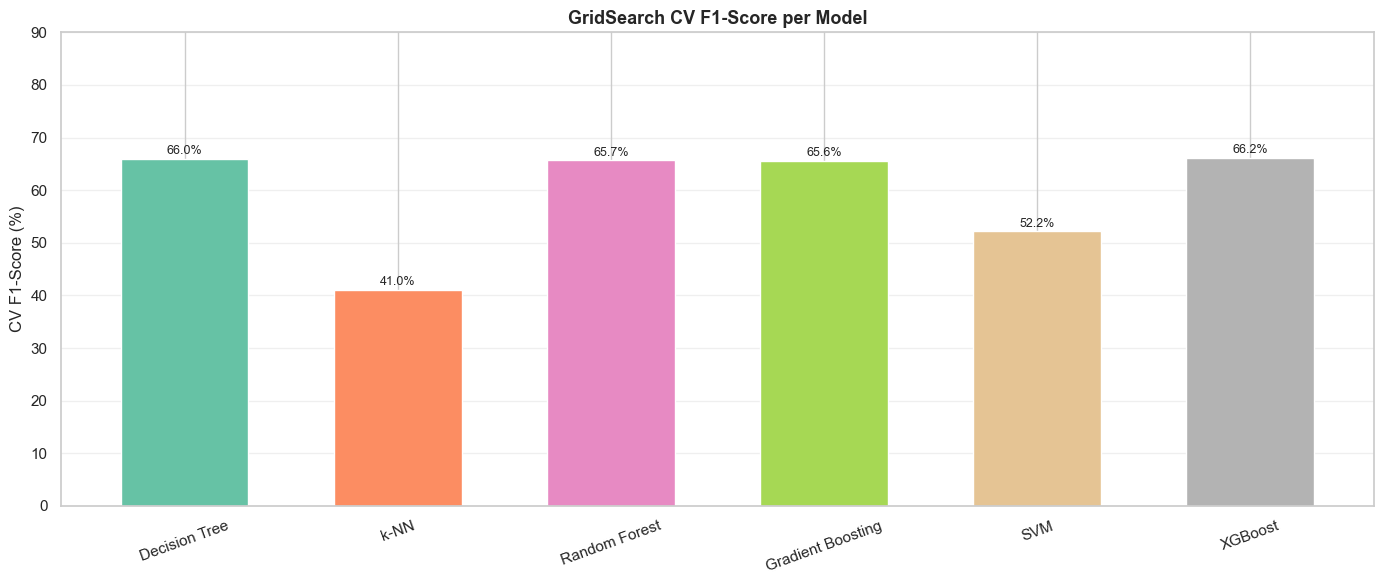

In [22]:
# Bar chart CV F1-Score
fig, ax = plt.subplots(figsize=(14, 6))
scores = [gs_results[m]['best_score'] for m in model_names]
colors_gs = plt.cm.Set2(np.linspace(0, 1, len(model_names)))
bars = ax.bar(model_names, scores, color=colors_gs, edgecolor='white', width=0.6)
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=9)
ax.set_title('GridSearch CV F1-Score per Model', fontsize=13, fontweight='bold')
ax.set_ylabel('CV F1-Score (%)')
ax.set_ylim(0, 90)
ax.tick_params(axis='x', rotation=20)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Eksperimen — 4 Skenario Preprocessing

Kombinasi **2 Scaler × 2 Resampler** = **4 skenario**:

| Skenario | Scaler | Resampler |
|---|---|---|
| S1 | StandardScaler | None (Baseline) |
| S2 | StandardScaler | SMOTE |
| S3 | MinMaxScaler | None (Baseline) |
| S4 | MinMaxScaler | SMOTE |

Semua skenario menggunakan model dengan hyperparameter hasil GridSearch.

In [23]:
SCALERS = {
    'StandardScaler': StandardScaler(),
    'MinMaxScaler':   MinMaxScaler(),
}
RESAMPLERS = {
    'None':       None,
    'SMOTE':      SMOTE(random_state=42),
}

def evaluate(model, X_tr, X_te, y_tr, y_te):
    """Evaluasi model dengan semua metrik."""
    m = copy.deepcopy(model)
    m.fit(X_tr, y_tr)
    yp = m.predict(X_te)
    # ROC-AUC
    try:
        yp_proba = m.predict_proba(X_te)[:, 1]
        auc = round(roc_auc_score(y_te, yp_proba) * 100, 2)
    except Exception:
        yp_proba = None
        auc = None
    return {
        'Accuracy':  round(accuracy_score(y_te, yp) * 100, 2),
        'Precision': round(precision_score(y_te, yp, zero_division=0) * 100, 2),
        'Recall':    round(recall_score(y_te, yp, zero_division=0) * 100, 2),
        'F1-Score':  round(f1_score(y_te, yp, zero_division=0) * 100, 2),
        'AUC':       auc,
        'y_pred':    yp,
        'y_proba':   yp_proba,
        'model':     m,
    }

results = {}
for sc_name, sc in SCALERS.items():
    results[sc_name] = {}
    Xtr_s = sc.fit_transform(X_train)
    Xte_s = sc.transform(X_test)
    for rs_name, rs in RESAMPLERS.items():
        results[sc_name][rs_name] = {}
        if rs is not None:
            Xtr_r, ytr_r = rs.fit_resample(Xtr_s, y_train)
        else:
            Xtr_r, ytr_r = Xtr_s, y_train
        for name in model_names:
            results[sc_name][rs_name][name] = evaluate(
                best_estimators[name], Xtr_r, Xte_s, ytr_r, y_test)
        print(f"   {sc_name} + {rs_name} selesai")

print("\n✅ Semua eksperimen selesai!")

   StandardScaler + None selesai
   StandardScaler + SMOTE selesai
   MinMaxScaler + None selesai
   MinMaxScaler + SMOTE selesai

✅ Semua eksperimen selesai!


## 7. Visualisasi Hasil

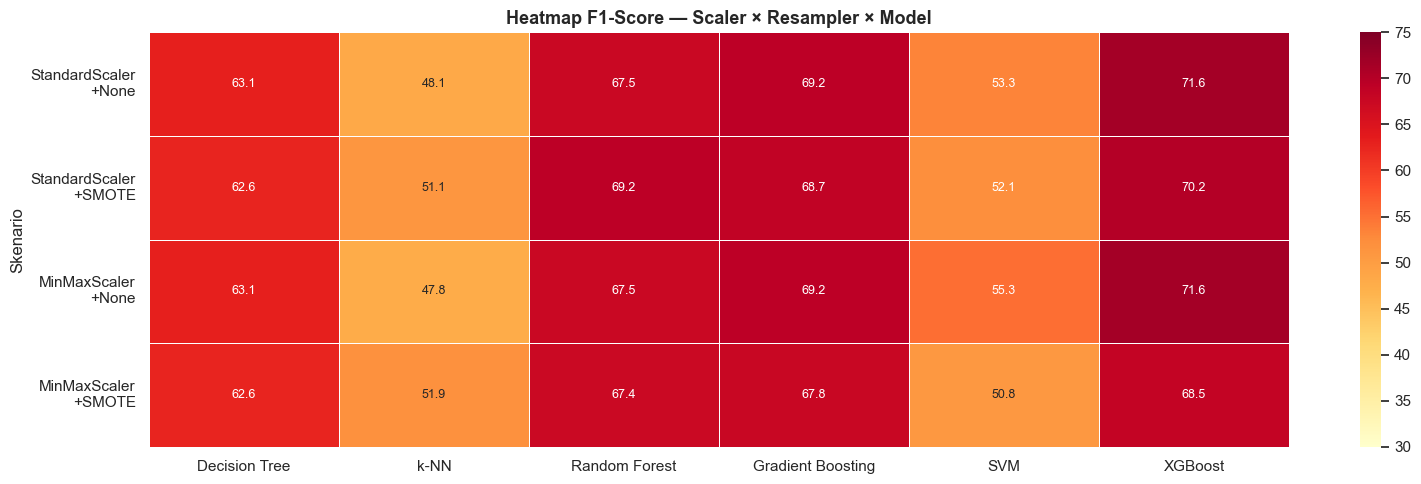

In [24]:
# Heatmap F1-Score
combo_labels = [f"{sc}\n+{rs}" for sc in SCALERS for rs in RESAMPLERS]
combo_keys   = [(sc, rs) for sc in SCALERS for rs in RESAMPLERS]

heat_data = pd.DataFrame(index=combo_labels, columns=model_names, dtype=float)
for (sc, rs), label in zip(combo_keys, combo_labels):
    for m in model_names:
        heat_data.loc[label, m] = results[sc][rs][m]['F1-Score']

fig, ax = plt.subplots(figsize=(16, 5))
sns.heatmap(heat_data.astype(float), annot=True, fmt='.1f', cmap='YlOrRd',
            ax=ax, linewidths=0.5, vmin=30, vmax=75,
            annot_kws={'size': 9})
ax.set_title('Heatmap F1-Score — Scaler × Resampler × Model',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Skenario')
plt.tight_layout()
plt.show()

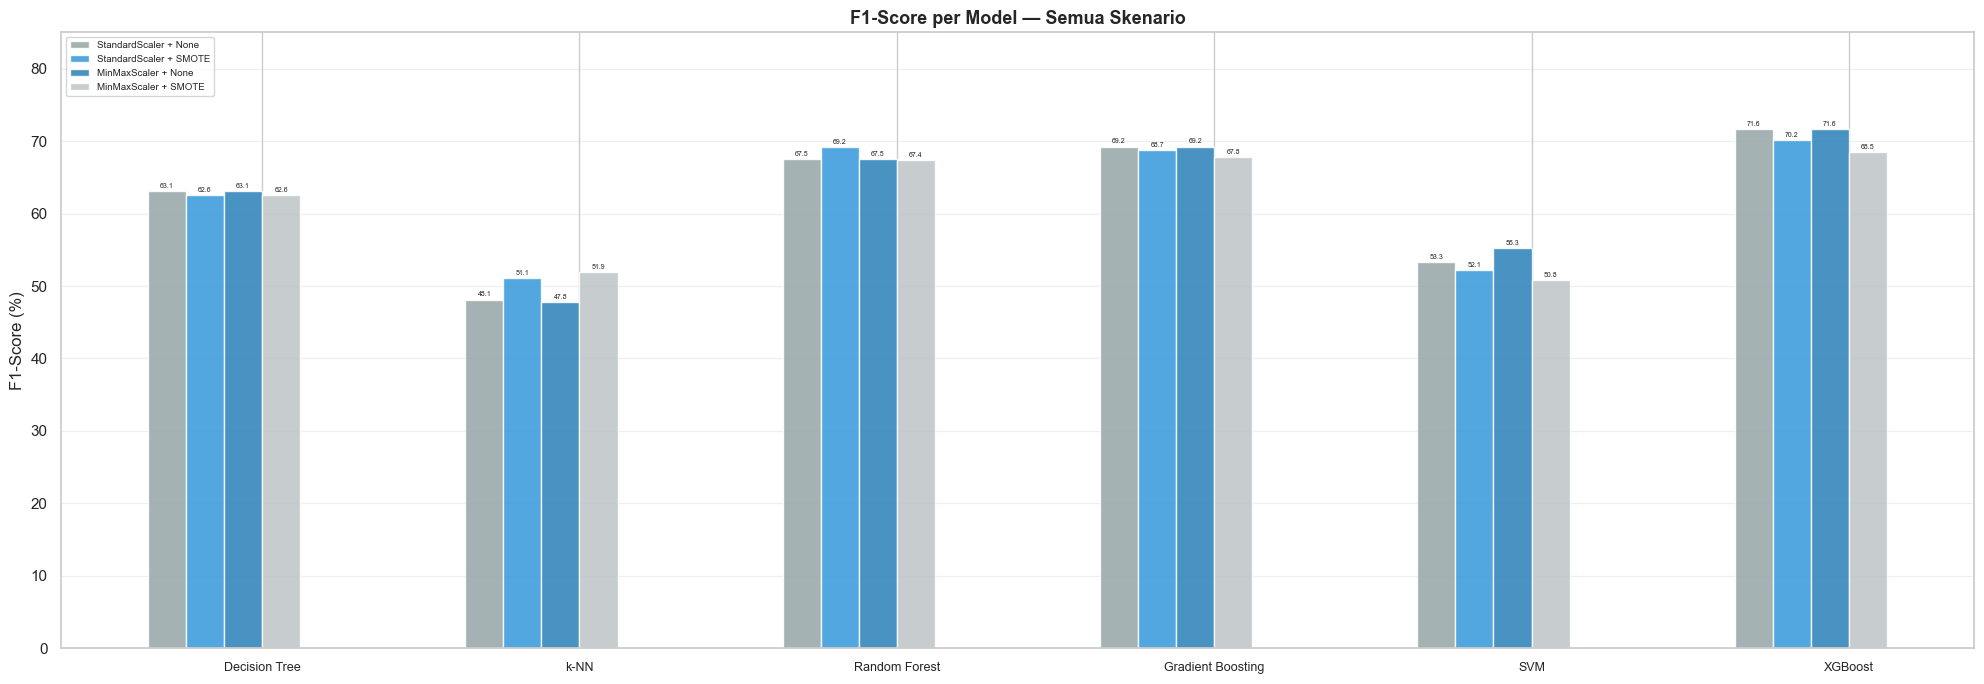

In [25]:
# Bar chart F1-Score semua skenario
colors_combo = ['#95a5a6', '#3498db', '#2980b9', '#bdc3c7', '#e74c3c', '#c0392b']

fig, ax = plt.subplots(figsize=(20, 7))
x = np.arange(len(model_names))
w = 0.12

for i, ((sc, rs), color) in enumerate(zip(combo_keys, colors_combo)):
    label = f"{sc} + {rs}"
    vals = [results[sc][rs][m]['F1-Score'] for m in model_names]
    bars = ax.bar(x + (i-2.5)*w, vals, w, label=label, color=color, alpha=0.85)
    for bar in bars:
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                f'{bar.get_height():.1f}', ha='center', va='bottom', fontsize=5)

ax.set_title('F1-Score per Model — Semua Skenario', fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(model_names, fontsize=9)
ax.set_ylabel('F1-Score (%)')
ax.set_ylim(0, 85)
ax.legend(fontsize=7, loc='upper left')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

Skenario terbaik: MinMaxScaler + None (avg F1 = 62.41%)


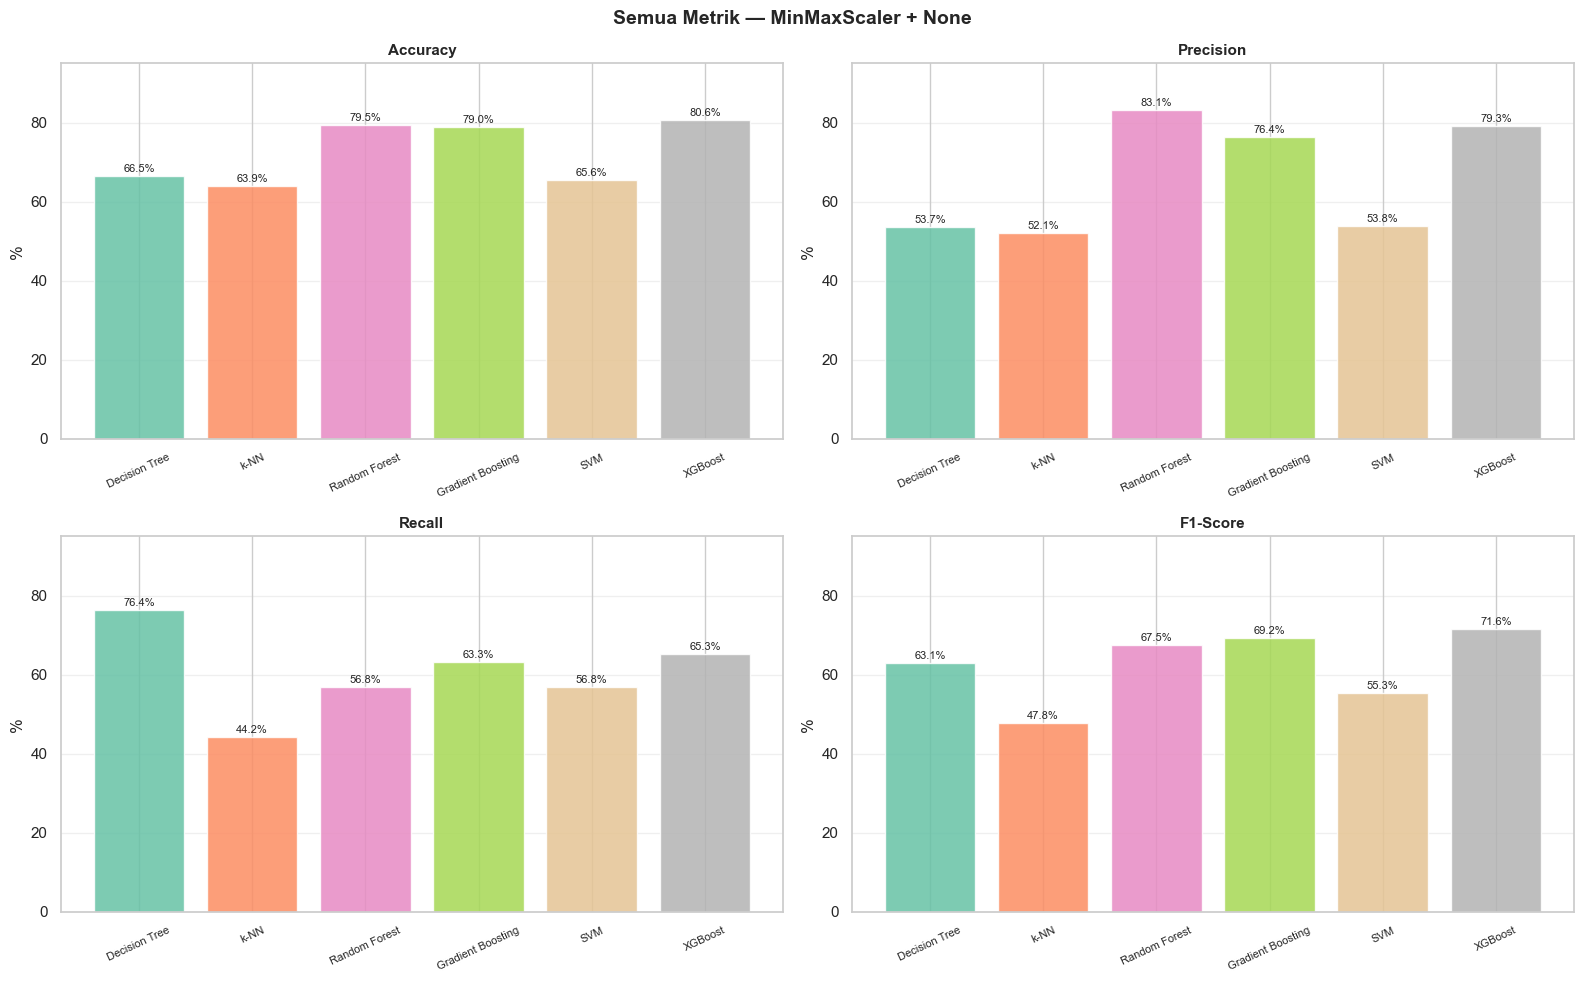

In [26]:
# Cari skenario terbaik berdasarkan rata-rata F1-Score
best_sc_g, best_rs_g, best_avg = '', '', 0
for sc in SCALERS:
    for rs in RESAMPLERS:
        avg = np.mean([results[sc][rs][m]['F1-Score'] for m in model_names])
        if avg > best_avg:
            best_avg, best_sc_g, best_rs_g = avg, sc, rs

print(f"Skenario terbaik: {best_sc_g} + {best_rs_g} (avg F1 = {best_avg:.2f}%)")

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
bar_colors = plt.cm.Set2(np.linspace(0, 1, len(model_names)))

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle(f'Semua Metrik — {best_sc_g} + {best_rs_g}',
             fontsize=14, fontweight='bold')
for idx, metric in enumerate(metrics):
    ax = axes[idx//2][idx%2]
    vals = [results[best_sc_g][best_rs_g][m][metric] for m in model_names]
    bars = ax.bar(model_names, vals, color=bar_colors, alpha=0.85, edgecolor='white')
    for bar in bars:
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=8)
    ax.set_title(metric, fontsize=11, fontweight='bold')
    ax.set_ylim(0, 95)
    ax.set_ylabel('%')
    ax.tick_params(axis='x', rotation=25, labelsize=8)
    ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 8. Confusion Matrix — Skenario Terbaik

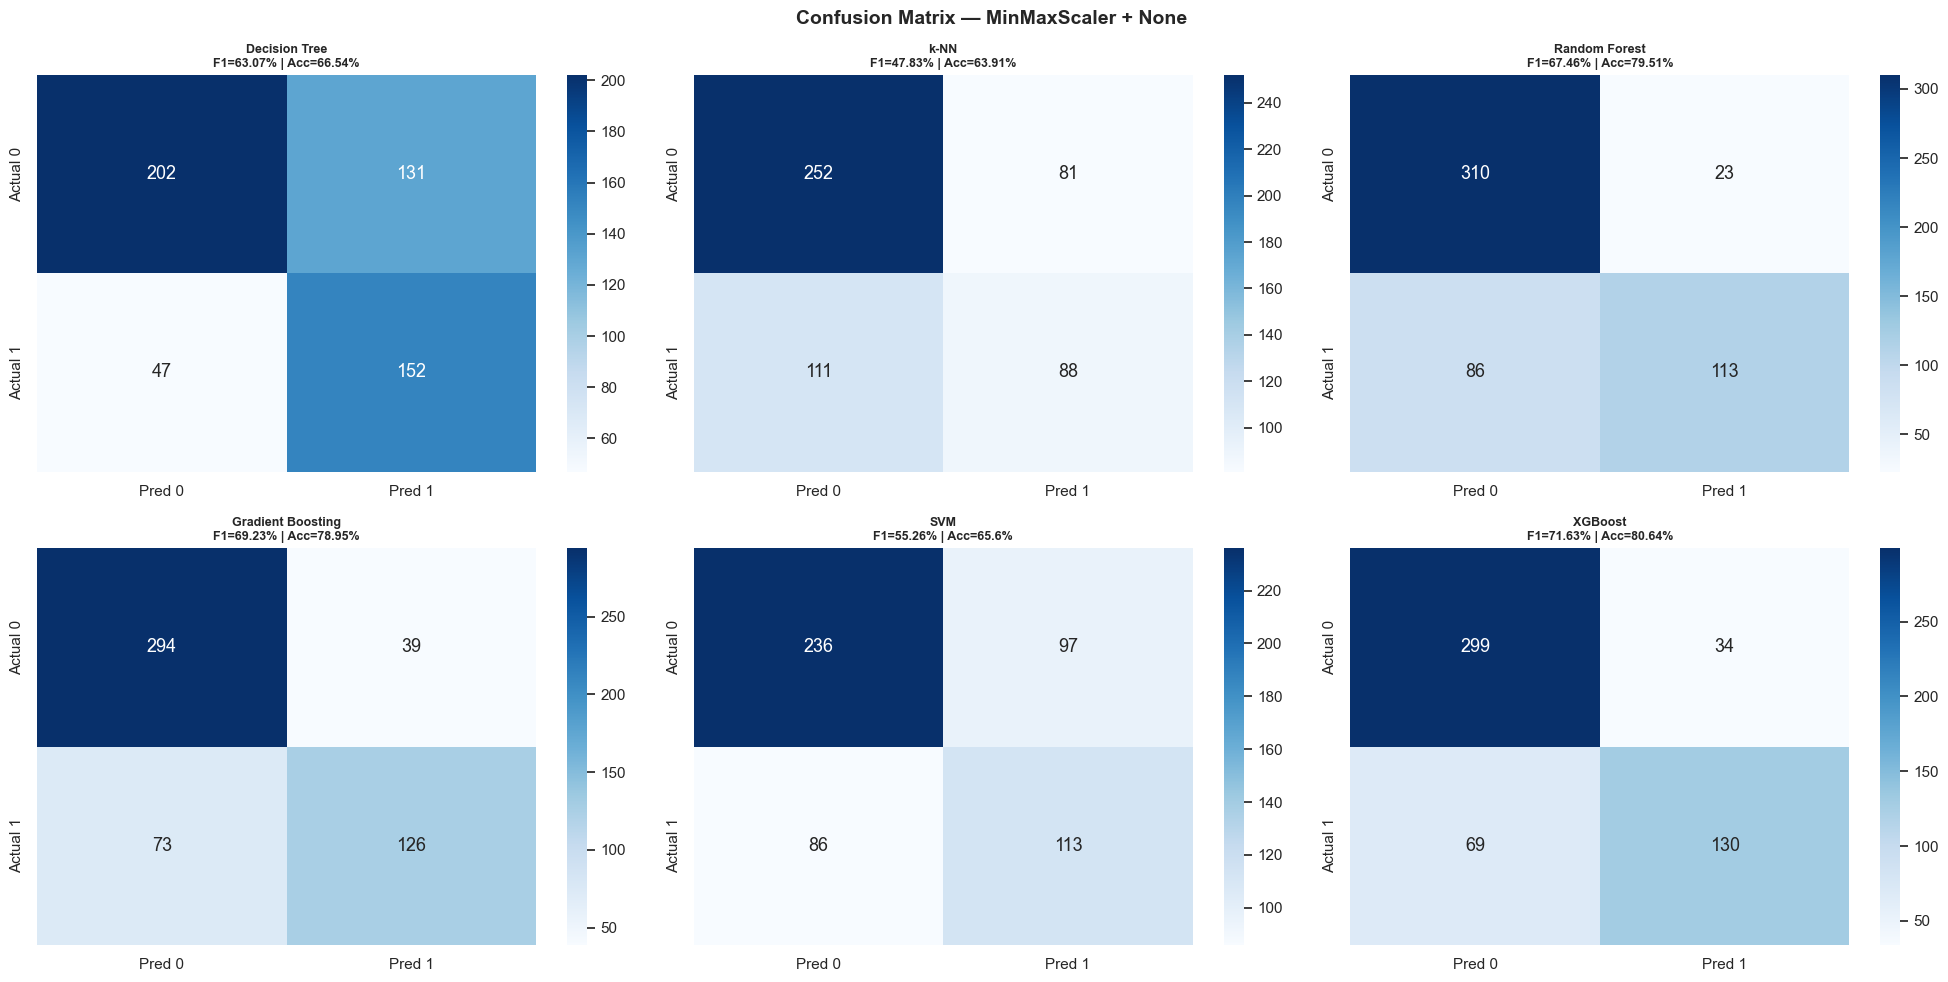

In [27]:
fig, axes = plt.subplots(2, 3, figsize=(20, 10))
fig.suptitle(f'Confusion Matrix — {best_sc_g} + {best_rs_g}',
             fontsize=14, fontweight='bold')
axes_flat = axes.flatten()

for i, name in enumerate(model_names):
    y_pred = results[best_sc_g][best_rs_g][name]['y_pred']
    cm = confusion_matrix(y_test, y_pred)
    f1  = results[best_sc_g][best_rs_g][name]['F1-Score']
    acc = results[best_sc_g][best_rs_g][name]['Accuracy']
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes_flat[i],
                xticklabels=['Pred 0','Pred 1'],
                yticklabels=['Actual 0','Actual 1'],
                annot_kws={'size': 13})
    axes_flat[i].set_title(f'{name}\nF1={f1}% | Acc={acc}%',
                           fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

## 9. ROC Curve — Skenario Terbaik
> Area Under the ROC Curve (AUC) mengukur kemampuan model membedakan kedua kelas

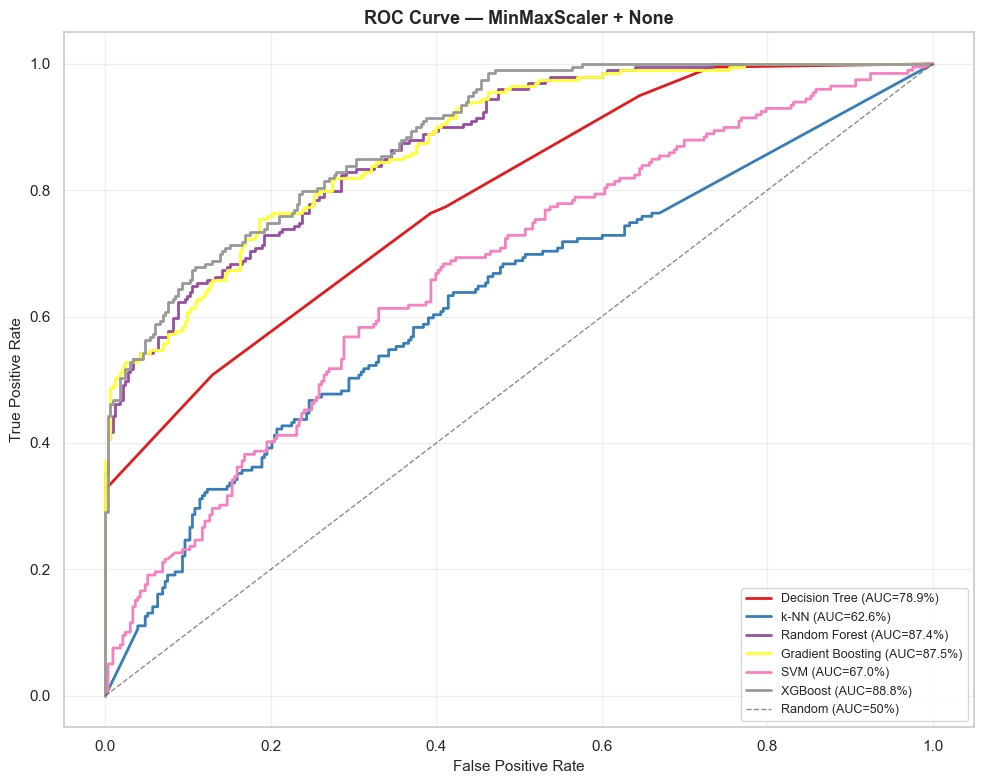

In [28]:
fig, ax = plt.subplots(figsize=(10, 8))
colors_roc = plt.cm.Set1(np.linspace(0, 1, len(model_names)))

for i, name in enumerate(model_names):
    y_proba = results[best_sc_g][best_rs_g][name]['y_proba']
    auc_val = results[best_sc_g][best_rs_g][name]['AUC']
    if y_proba is not None:
        fpr, tpr, _ = roc_curve(y_test, y_proba)
        ax.plot(fpr, tpr, color=colors_roc[i], linewidth=2,
                label=f'{name} (AUC={auc_val:.1f}%)')

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.5, label='Random (AUC=50%)')
ax.set_xlabel('False Positive Rate', fontsize=11)
ax.set_ylabel('True Positive Rate', fontsize=11)
ax.set_title(f'ROC Curve — {best_sc_g} + {best_rs_g}', fontsize=13, fontweight='bold')
ax.legend(fontsize=9, loc='lower right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 10. Classification Report — Skenario Terbaik
> Precision, Recall, dan F1-Score per kelas untuk setiap model

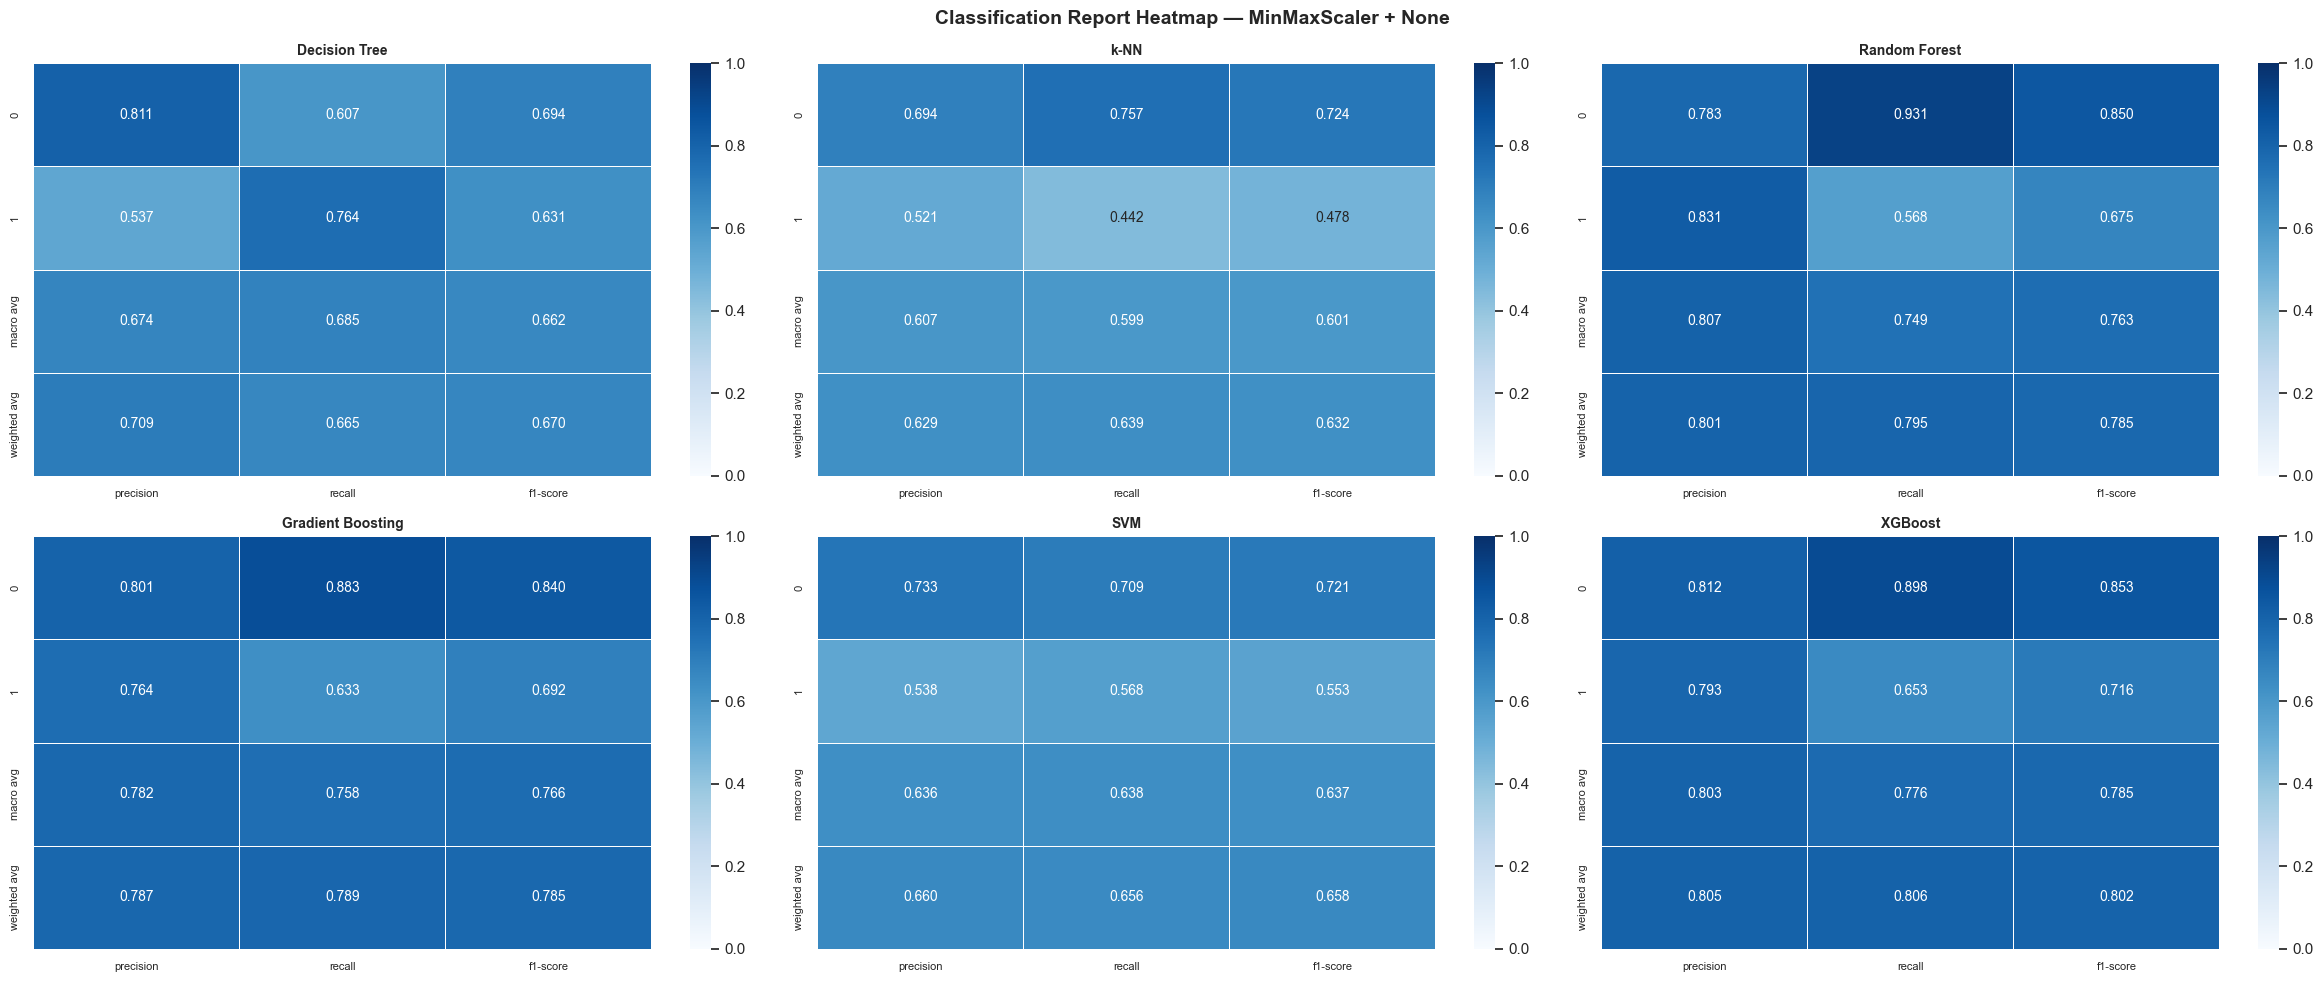

In [29]:
fig, axes = plt.subplots(2, 3, figsize=(24, 10))
fig.suptitle(f'Classification Report Heatmap — {best_sc_g} + {best_rs_g}',
             fontsize=14, fontweight='bold')
axes_flat = axes.flatten()

for i, name in enumerate(model_names):
    y_pred = results[best_sc_g][best_rs_g][name]['y_pred']
    cr = pd.DataFrame(classification_report(y_test, y_pred, digits=3, output_dict=True)).T
    cr = cr.drop(columns='support', errors='ignore')
    cr = cr.drop('accuracy', errors='ignore')
    sns.heatmap(cr, cmap='Blues', annot=True, fmt='.3f',
                linewidths=0.5, ax=axes_flat[i], vmin=0, vmax=1,
                annot_kws={'size': 10})
    axes_flat[i].set_title(name, fontsize=10, fontweight='bold')
    axes_flat[i].tick_params(axis='both', labelsize=8)

plt.tight_layout()
plt.show()

## 11. Radar Chart — Perbandingan Metrik per Model

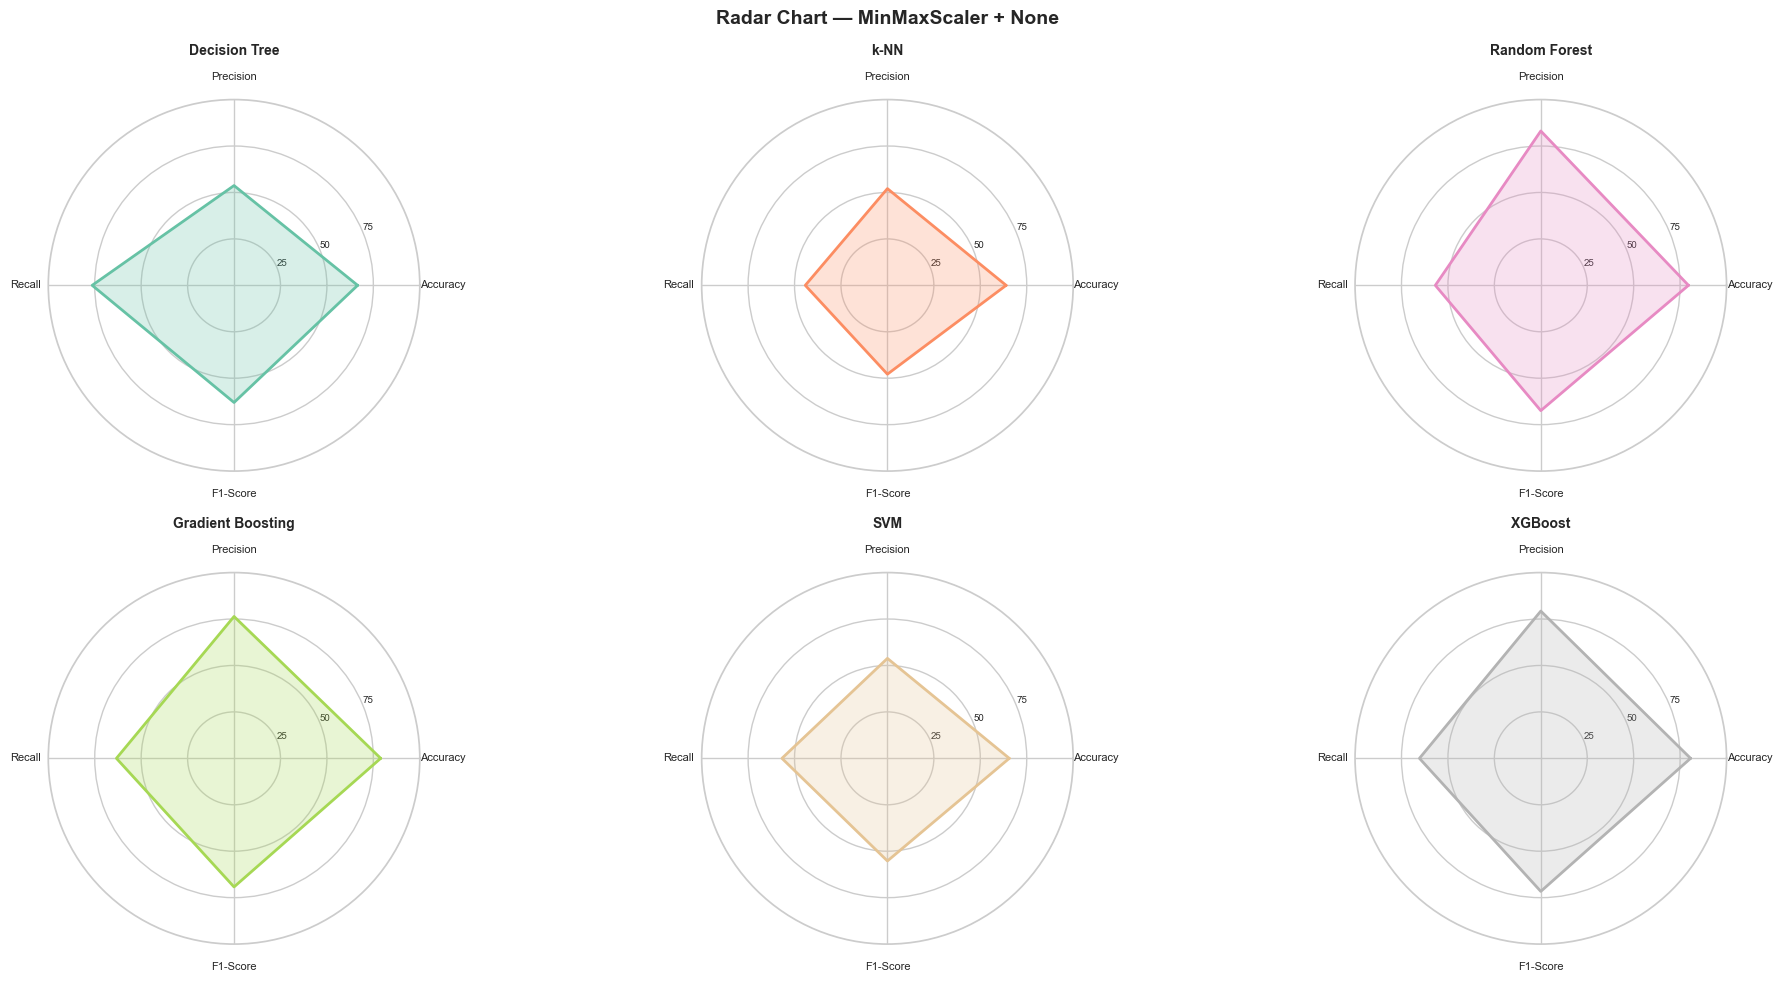

In [30]:
cats = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
N = len(cats)
angles = [n/float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

fig, axes = plt.subplots(2, 3, figsize=(20, 10), subplot_kw=dict(polar=True))
fig.suptitle(f'Radar Chart — {best_sc_g} + {best_rs_g}', fontsize=14, fontweight='bold')
axes_flat = axes.flatten()
colors_radar = plt.cm.Set2(np.linspace(0, 1, len(model_names)))

for i, (name, color) in enumerate(zip(model_names, colors_radar)):
    vals = [results[best_sc_g][best_rs_g][name][c] for c in cats]
    vals += vals[:1]
    axes_flat[i].plot(angles, vals, color=color, linewidth=2)
    axes_flat[i].fill(angles, vals, color=color, alpha=0.25)
    axes_flat[i].set_xticks(angles[:-1])
    axes_flat[i].set_xticklabels(cats, fontsize=8)
    axes_flat[i].set_ylim(0, 100)
    axes_flat[i].set_yticks([25, 50, 75])
    axes_flat[i].set_yticklabels(['25', '50', '75'], fontsize=7)
    axes_flat[i].set_title(name, fontsize=10, fontweight='bold', pad=12)

plt.tight_layout()
plt.show()

## 12. Feature Importance
> Feature importance dari model tree-based, menunjukkan fitur mana yang paling berpengaruh

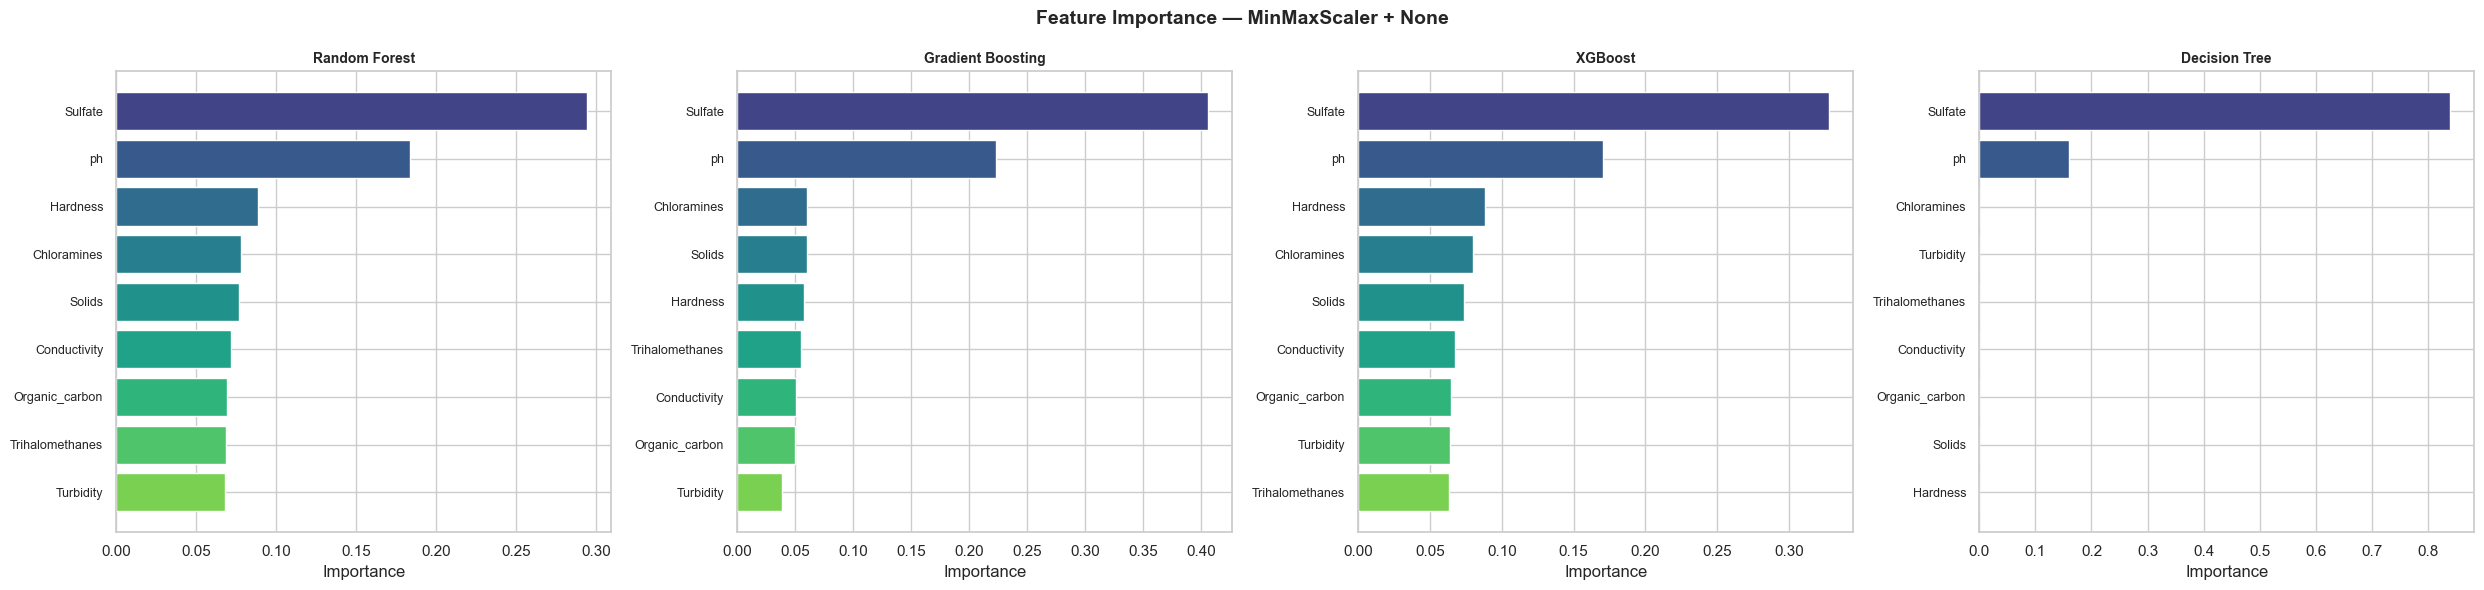

In [31]:
# Feature Importance dari model tree-based
tree_models = ['Random Forest', 'Gradient Boosting', 'XGBoost', 'Decision Tree']

fig, axes = plt.subplots(1, len(tree_models), figsize=(25, 6))
fig.suptitle(f'Feature Importance — {best_sc_g} + {best_rs_g}',
             fontsize=14, fontweight='bold')

for i, name in enumerate(tree_models):
    model_obj = results[best_sc_g][best_rs_g][name]['model']
    if hasattr(model_obj, 'feature_importances_'):
        importances = model_obj.feature_importances_
        indices = np.argsort(importances)[::-1]
        feat_names = X.columns[indices]

        axes[i].barh(range(len(feat_names)), importances[indices],
                     color=plt.cm.viridis(np.linspace(0.2, 0.8, len(feat_names))))
        axes[i].set_yticks(range(len(feat_names)))
        axes[i].set_yticklabels(feat_names, fontsize=9)
        axes[i].set_title(name, fontsize=10, fontweight='bold')
        axes[i].set_xlabel('Importance')
        axes[i].invert_yaxis()

plt.tight_layout()
plt.show()

## 13. Ranking Final & Kesimpulan

In [95]:
best_per_model = []
for name in model_names:
    best_f1, best_sc_m, best_rs_m = 0, '', ''
    for sc in SCALERS:
        for rs in RESAMPLERS:
            f1 = results[sc][rs][name]['F1-Score']
            if f1 > best_f1:
                best_f1, best_sc_m, best_rs_m = f1, sc, rs
    r = results[best_sc_m][best_rs_m][name]
    best_per_model.append({
        'Model': name, 'Scaler': best_sc_m, 'Resampler': best_rs_m,
        'Accuracy (%)': r['Accuracy'], 'Precision (%)': r['Precision'],
        'Recall (%)': r['Recall'], 'F1-Score (%)': r['F1-Score'],
        'AUC (%)': r['AUC'] if r['AUC'] else 'N/A',
    })

df_rank = pd.DataFrame(best_per_model).sort_values('F1-Score (%)', ascending=False).reset_index(drop=True)
df_rank.index += 1
df_rank

,Model,Scaler,Resampler,Accuracy (%),Precision (%),Recall (%),F1-Score (%),AUC (%)
1,XGBoost,StandardScaler,None,80.64,79.27,65.33,71.63,88.77
2,Gradient Boosting,StandardScaler,None,78.95,76.36,63.32,69.23,87.49
3,Random Forest,StandardScaler,SMOTE,77.26,70.10,68.34,69.21,86.63
4,Decision Tree,StandardScaler,None,66.54,53.71,76.38,63.07,78.88
5,SVM,MinMaxScaler,None,65.60,53.81,56.78,55.26,66.96
6,k-NN,MinMaxScaler,SMOTE,59.59,46.77,58.29,51.90,61.49


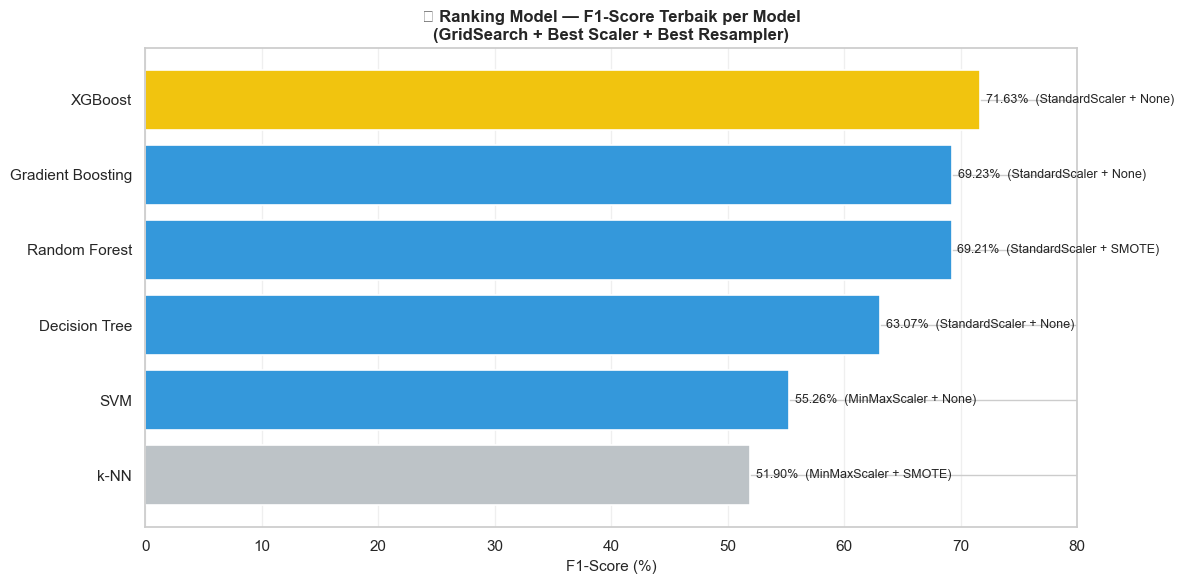

In [96]:
fig, ax = plt.subplots(figsize=(12, 6))
bar_c = ['#f1c40f' if i == 0 else ('#bdc3c7' if i == len(df_rank)-1 else '#3498db')
         for i in range(len(df_rank))]
bars = ax.barh(df_rank['Model'], df_rank['F1-Score (%)'],
               color=bar_c, edgecolor='white', linewidth=1.2)
ax.set_xlabel('F1-Score (%)', fontsize=11)
ax.set_title('🏆 Ranking Model — F1-Score Terbaik per Model\n(GridSearch + Best Scaler + Best Resampler)',
             fontsize=12, fontweight='bold')
ax.set_xlim(0, 80)
ax.invert_yaxis()
for i, bar in enumerate(bars):
    sc = df_rank.iloc[i]['Scaler']
    rs = df_rank.iloc[i]['Resampler']
    ax.text(bar.get_width()+0.5, bar.get_y()+bar.get_height()/2,
            f"{bar.get_width():.2f}%  ({sc} + {rs})",
            va='center', fontsize=9)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Eksperimen — 4 Skenario Preprocessing

Kombinasi **2 Scaler × 2 Resampler** = **4 skenario**:

| Skenario | Scaler | Resampler |
|---|---|---|
| S1 | StandardScaler | None (Baseline) |
| S2 | StandardScaler | SMOTE |
| S3 | MinMaxScaler | None (Baseline) |
| S4 | MinMaxScaler | SMOTE |

Semua skenario menggunakan model dengan hyperparameter hasil GridSearch.